<a href="https://colab.research.google.com/github/SHRESHTH121/HandsOnMachineLearning/blob/main/LinearRegressionFromScratchUsingGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X=2*np.random.rand(100,1)
y=4+3*X+np.random.randn(100,1)

<Axes: >

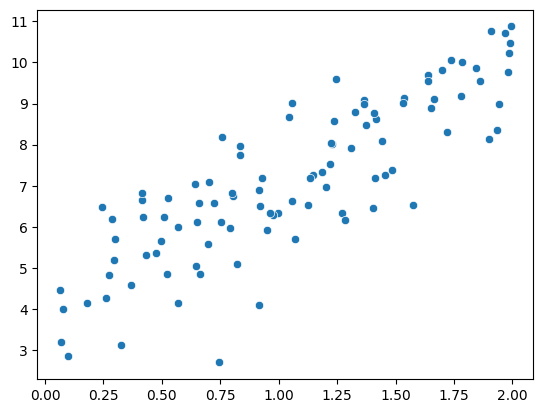

In [ ]:
sns.scatterplot(x=X.flatten(),y=y.flatten())

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

# **Batch Gradient Descent**

In [ ]:
class LinearRegression(BaseEstimator, RegressorMixin):

    def __init__(self, eta=0.01, n_iterations=1000):
        self.eta = eta
        self.n_iterations = n_iterations

    def fit(self, X, y):

        X = np.insert(X, 0, 1, axis=1)
        y = y.reshape(-1, 1)

        m = X.shape[0]

        self.theta = np.random.randn(X.shape[1], 1)

        for _ in range(self.n_iterations):

            gradient = (1/m) * X.T.dot(X.dot(self.theta) - y)

            self.theta -= self.eta * gradient

        self.intercept_ = self.theta[0]
        self.coef_ = self.theta[1:]

        return self

    def predict(self, X):

        X = np.insert(X, 0, 1, axis=1)

        return X.dot(self.theta)

### stochastic and mini batch same just a small change in m value and numer of iterations

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X,y)

LinearRegression()

In [ ]:
lr.coef_

array([[3.17226941]])

In [ ]:
lr.intercept_

array([3.76040598])

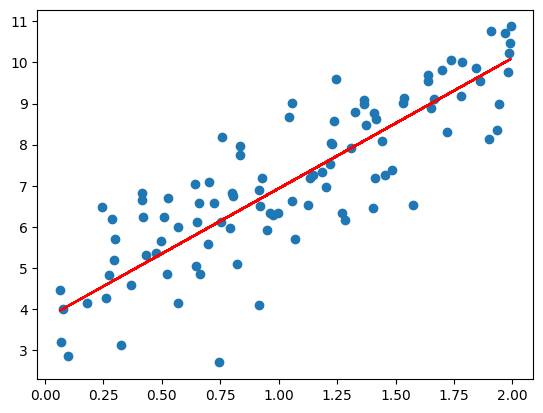

In [ ]:
from seaborn.palettes import color_palette
plt.scatter(X.flatten(),y.flatten())
plt.plot(X.flatten(),lr.predict(X).flatten(),color='red')

Or we can import SGDRegressor from sklearn.linear_model to implement stochastic gd